In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.utils import resample
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

OPIS SKUPA PODATAKA

The dataset consists of 10 numerical and 8 categorical attributes.
The 'Revenue' attribute can be used as the class label.

"Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories. The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another. The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session. The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session. The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction. The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8. The dataset also includes operating system, browser, region, traffic type, visitor type as returning or new visitor, a Boolean value indicating whether the date of the visit is weekend, and month of the year.

In [ ]:
def plot_clusters_pca(X, labels, title):
    X = np.array(X)
    if X.ndim == 1:
        raise ValueError("Input data X must be 2D for plotting clusters.")
    if X.shape[1] < 2:
        raise ValueError("Input data X must have at least two features (columns) for 2D plotting.")
    print(title,"Silhouette:", silhouette_score(X, labels) if len(set(labels)) > 1 else "N/A")
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], cmap='tab10', s=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [ ]:
def plot_clusters(X, labels, title):
    X = np.array(X)
    if X.ndim == 1:
        raise ValueError("Input data X must be 2D for plotting clusters.")
    if X.shape[1] < 2:
        raise ValueError("Input data X must have at least two features (columns) for 2D plotting.")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    # print(title,"Silhouette:", silhouette_score(X, labels) if len(set(labels)) > 1 else "N/A")
    plt.figure(figsize=(6, 5))
    # plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab10', s=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [ ]:
def metrike(title,X,labels):
    print("Silhouette +",title,":", silhouette_score(X, labels))
    print("Davies-Bouldin indeks: +",title,":", davies_bouldin_score(X, labels))

In [ ]:
def cluster1(model, title, X):
    model.fit(X)
    labels = model.labels_
    metrike(title, X, labels)

In [ ]:
def cluster2(model, title, X):
    labels = model.fit_predict(X)
    metrike(title, X, labels)

In [40]:
df = pd.read_csv(r'podaci\online+shoppers+purchasing+intention+dataset\online_shoppers_intention preprocessed.csv', encoding='cp1252', sep=',')
print(df.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')


In [41]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [42]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [43]:
X = df.copy(deep=True)

In [44]:
X = X.drop('Revenue', axis=1)

In [45]:
engagement_features = ["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated",
        "ProductRelated_Duration","BounceRates","ExitRates","PageValues"]
technical_features = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
time_features = ["SpecialDay","Month","Weekend"]

In [46]:
numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues"
]

In [47]:
scaler = StandardScaler()
pca = PCA(n_components=2)

In [48]:
X_log = X.copy(deep=True)
X_sca = X.copy(deep=True)

In [49]:
X_log[numeric_features] = np.log1p(X_log[numeric_features])
X_sca[numeric_features] = scaler.fit_transform(X[numeric_features])
X_pca = pca.fit_transform(X)
X_pca_sca = pca.fit_transform(X_sca)

# X_eng_pca = pca.fit_transform(X[engagement_features])
# X_tec_pca = pca.fit_transform(X[technical_features])
# X_time_pca = pca.fit_transform(X[time_features])

In [52]:
cols = X.columns
n_cols = 2
n_rows = len(cols)
scaled_df = pd.DataFrame(X_sca, columns=X.columns, index=X.index)

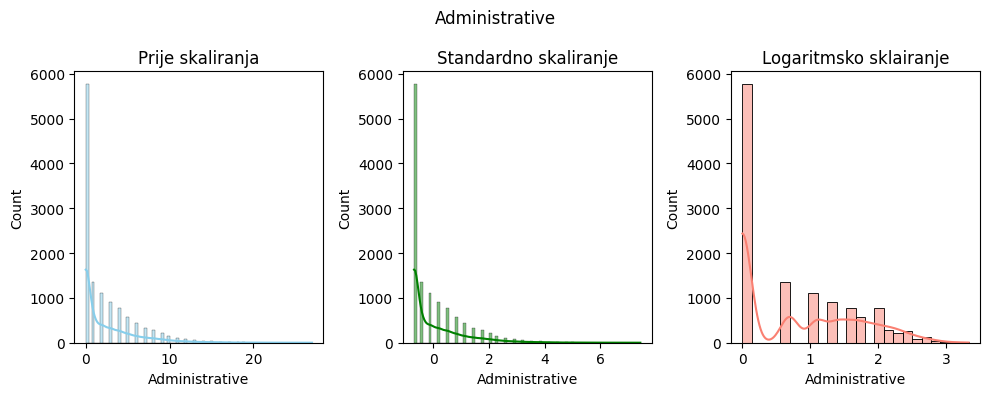

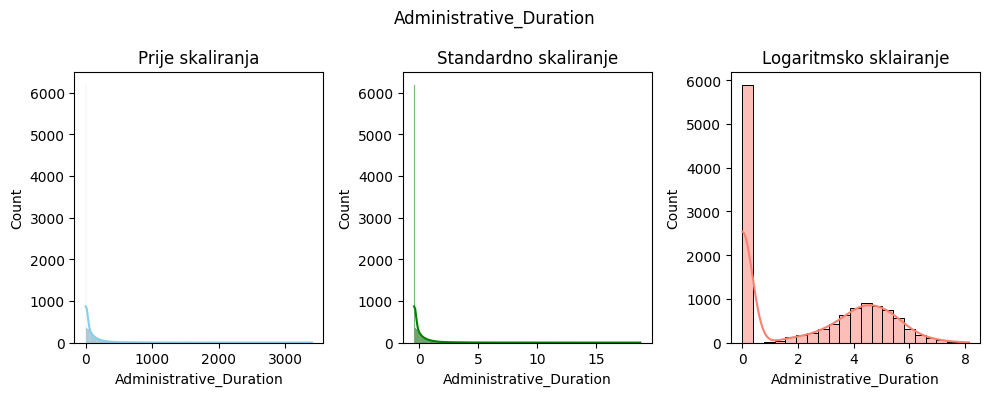

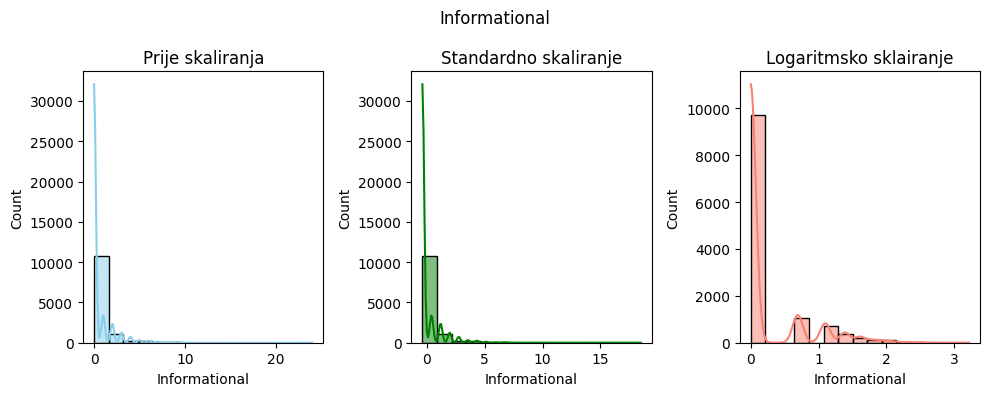

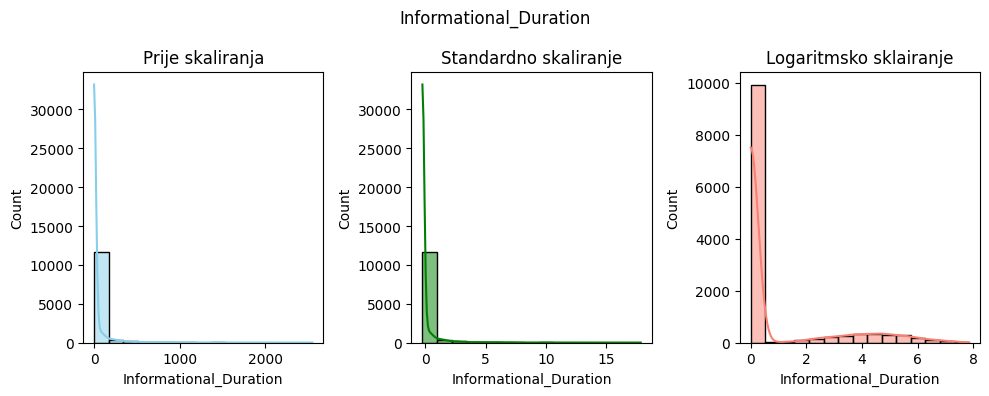

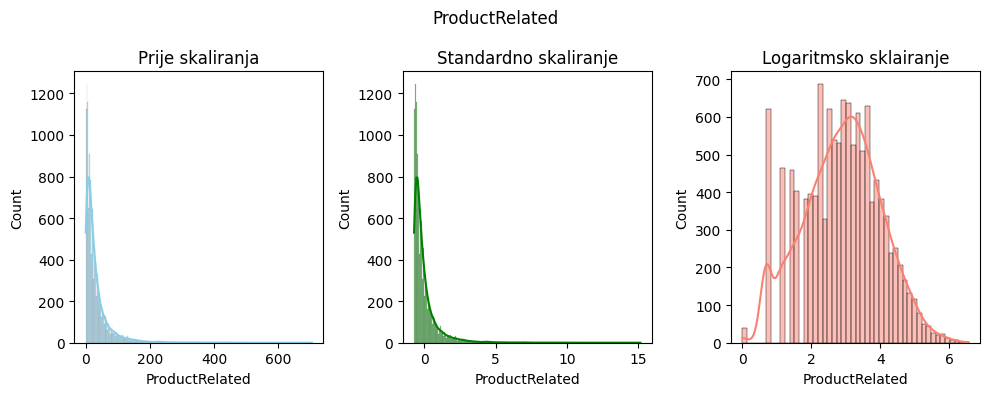

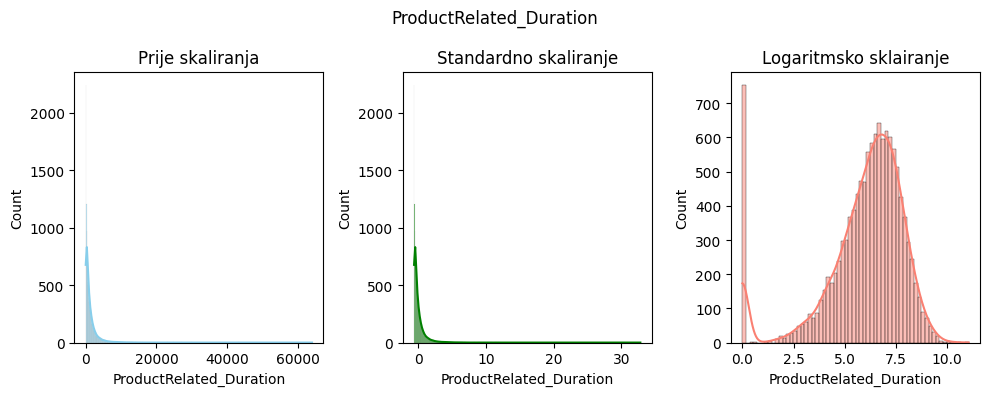

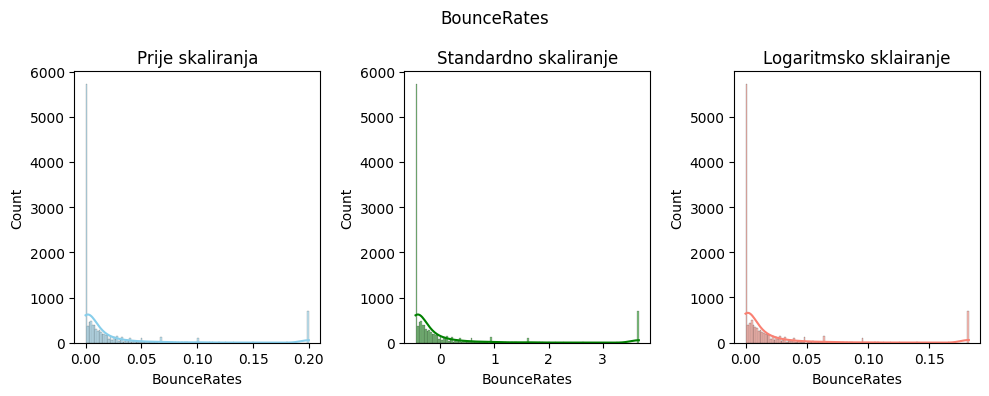

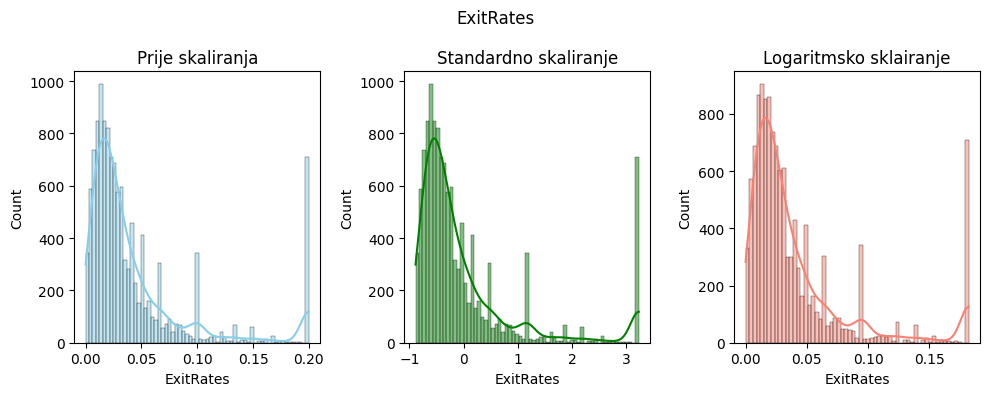

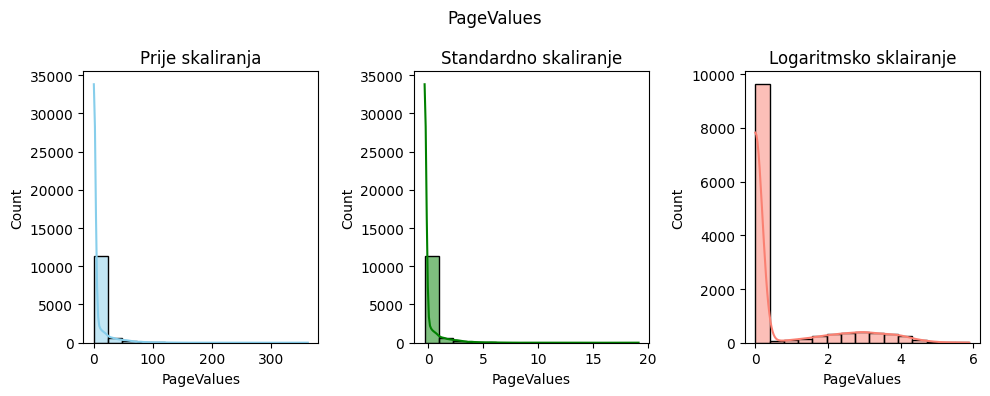

In [59]:
cols_to_plot = ["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated",
        "ProductRelated_Duration","BounceRates","ExitRates","PageValues"]

for col in cols_to_plot:
    plt.figure(figsize=(10,4))
    plt.suptitle(f'{col}')

    # Prije
    plt.subplot(1,3,1)
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f"Prije skaliranja")

    # Poslije
    plt.subplot(1,3,3)
    sns.histplot(X_log[col], kde=True, color="salmon")
    plt.title(f"Logaritmsko sklairanje")

    plt.subplot(1,3,2)
    sns.histplot(X_sca[col], kde=True, color="green")
    plt.title(f"Standardno skaliranje")

    plt.tight_layout()
    plt.show()

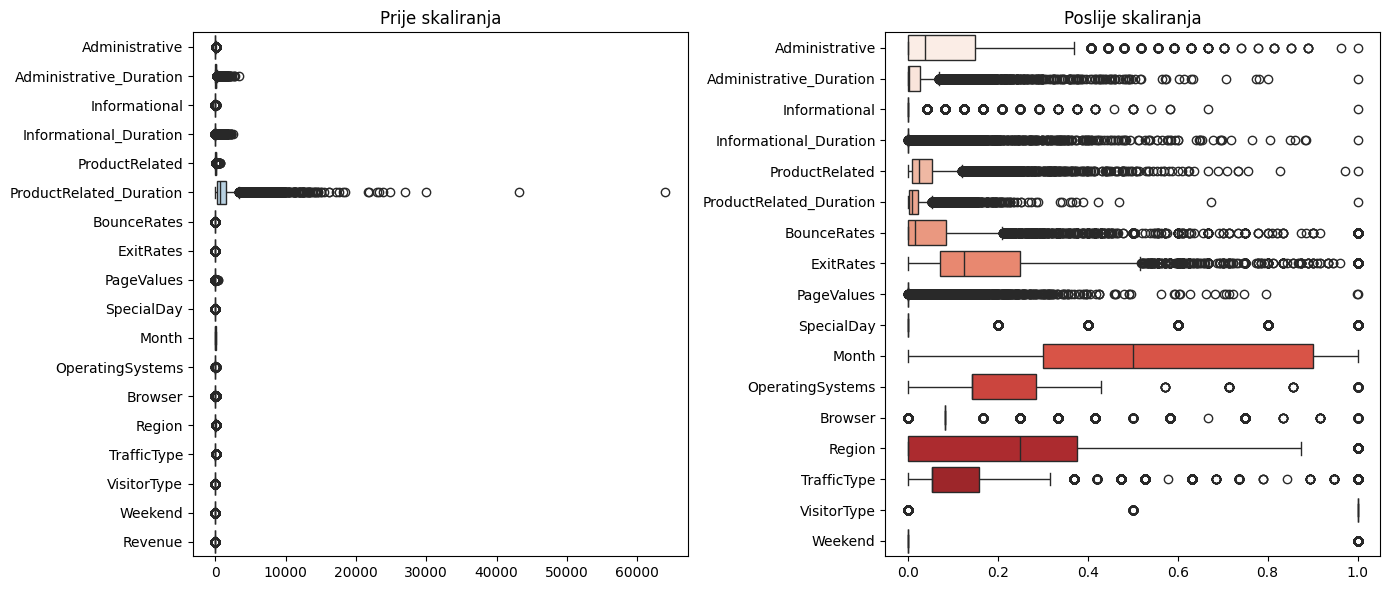

In [16]:
plt.figure(figsize=(14, 6))

# Prije skaliranja
plt.subplot(1, 2, 1)
sns.boxplot(data=df, orient="h", palette="Blues")
plt.title("Prije skaliranja")

# Poslije skaliranja
plt.subplot(1, 2, 2)
sns.boxplot(data=scaled_df, orient="h", palette="Reds")
plt.title("Poslije skaliranja")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.cluster import MiniBatchKMeans

for i in range(2,3):
    mb_kmeans = MiniBatchKMeans(n_clusters=i, random_state=123)
    
    print("---------------- Broj klastera ",i,"--------------------")

    cluster1(mb_kmeans,"X",X)
    cluster1(mb_kmeans,"Xlog",X_log)
    cluster1(mb_kmeans,"X_sca",X_sca)
    cluster1(mb_kmeans,"X_pca",X_pca)
    cluster1(mb_kmeans,"X_pca_sca",X_pca_sca)

    # cluster1(mb_kmeans,"X_eng_pca",X_eng_pca)
    # cluster1(mb_kmeans,"X_time_pca",X_time_pca)
    # cluster1(mb_kmeans,"X_tec_pca",X_tec_pca)

---------------- Broj klastera  2 --------------------
Silhouette + X : 0.7646687965821284
Davies-Bouldin indeks: + X : 0.5847854441837779
Silhouette + Xlog : 0.33173102708793467
Davies-Bouldin indeks: + Xlog : 1.35719424594948
Silhouette + X_sca : 0.3064692696603802
Davies-Bouldin indeks: + X_sca : 1.4386392294197796
Silhouette + X_pca : 0.770085009300966
Davies-Bouldin indeks: + X_pca : 0.5742537565652022
Silhouette + X_pca_sca : 0.6343407770153795
Davies-Bouldin indeks: + X_pca_sca : 0.5883522607315531


In [21]:
from sklearn.cluster import SpectralClustering

for i in range(2,3):
    spectral = SpectralClustering(n_clusters=i, affinity='nearest_neighbors', random_state=123)

    print("---------------- Broj klastera ",i,"--------------------")
    
    cluster2(spectral,"X",X)
    cluster2(spectral,"Xlog",X_log)
    cluster2(spectral,"X_sca",X_sca)
    cluster2(spectral,"X_pca",X_pca)
    cluster2(spectral,"X_pca_sca",X_pca_sca)

    # cluster2(spectral,"X_eng_pca",X_eng_pca)
    # cluster2(spectral,"X_time_pca",X_time_pca)
    # cluster2(spectral,"X_tec_pca",X_tec_pca)

---------------- Broj klastera  2 --------------------
Silhouette + X : 0.49837829258546096
Davies-Bouldin indeks: + X : 0.7741776163906051


KeyboardInterrupt: 

In [ ]:
from sklearn.cluster import KMeans

for i in range(2,3):
    kmeans = KMeans(n_clusters=i , init='k-means++', random_state=123)
    
    print("---------------- Broj klastera ",i,"--------------------")
    
    cluster2(kmeans,"X",X)
    cluster2(kmeans,"Xlog",X_log)
    cluster2(kmeans,"X_sca",X_sca)
    cluster2(kmeans,"X_pca",X_pca)
    cluster2(kmeans,"X_pca_sca",X_pca_sca)

    # cluster2(kmeans,"X_eng_pca",X_eng_pca)
    # cluster2(kmeans,"X_time_pca",X_time_pca)
    # cluster2(kmeans,"X_tec_pca",X_tec_pca)

---------------- Broj klastera  2 --------------------
Silhouette + X : 0.7809884192698832
Davies-Bouldin indeks: + X : 0.5568667106929692
Silhouette + Xlog : 0.20640683021299341
Davies-Bouldin indeks: + Xlog : 1.9234598339187272
Silhouette + X_sca : 0.270202405911401
Davies-Bouldin indeks: + X_sca : 1.9008196192360132
Silhouette + X_pca : 0.7832243900602182
Davies-Bouldin indeks: + X_pca : 0.5513748253871039
Silhouette + X_pca_sca : 0.6343407770153795
Davies-Bouldin indeks: + X_pca_sca : 0.5883522607315531
Silhouette + X_eng_pca : 0.7832244003481015
Davies-Bouldin indeks: + X_eng_pca : 0.551374844363637
Silhouette + X_time_pca : 0.7600857962226294
Davies-Bouldin indeks: + X_time_pca : 0.3342923471883845
Silhouette + X_tec_pca : 0.6439209546256711
Davies-Bouldin indeks: + X_tec_pca : 0.6214569311554086


In [ ]:
from sklearn.cluster import Birch

for i in range(2,3):
    birch = Birch(n_clusters=i)
    
    print("---------------- Broj klastera ",i,"--------------------")
    
    cluster1(birch,"X",X)
    cluster1(birch,"Xlog",X_log)
    cluster1(birch,"X_sca",X_sca)
    cluster1(birch,"X_pca",X_pca)
    cluster1(birch,"X_pca_sca",X_pca_sca)

    # cluster1(birch,"X_eng_pca",X_eng_pca)
    # cluster1(birch,"X_time_pca",X_time_pca)
    # cluster1(birch,"X_tec_pca",X_tec_pca)

---------------- Broj klastera  2 --------------------
Silhouette + X : 0.8346583258006888
Davies-Bouldin indeks: + X : 0.44701644053737744
Silhouette + Xlog : 0.31151072069891417
Davies-Bouldin indeks: + Xlog : 1.4343157201933914
Silhouette + X_sca : 0.31885906101146577
Davies-Bouldin indeks: + X_sca : 1.4142336943210905
Silhouette + X_pca : 0.820108029280827
Davies-Bouldin indeks: + X_pca : 0.474378410513152
Silhouette + X_pca_sca : 0.6343407770153795
Davies-Bouldin indeks: + X_pca_sca : 0.5883522607315531
Silhouette + X_eng_pca : 0.7458665616242396
Davies-Bouldin indeks: + X_eng_pca : 0.6102519512867391
Silhouette + X_time_pca : 0.7569588276929173
Davies-Bouldin indeks: + X_time_pca : 0.33151563003994255
Silhouette + X_tec_pca : 0.6439606090501943
Davies-Bouldin indeks: + X_tec_pca : 0.6089426317459662


In [ ]:
import faiss
X_faiss = X_pca.astype(np.float32)

for i in range(2,7):
    faiss_kmeans = faiss.Kmeans(d=X_faiss.shape[1], k=i)
    faiss_kmeans.train(X_faiss)

    D, I = faiss_kmeans.index.search(X_faiss, 1)
    labels_faiss = I.flatten()
    metrike("X_pca",X_pca,labels_faiss)
    # plot_clusters(X_pca, labels_faiss, 'Faiss KMeans + PCA')

Silhouette + X_pca : 0.8030100911399585
Davies-Bouldin indeks: + X_pca : 0.5121340130346674
Silhouette + X_pca : 0.6582117665732378
Davies-Bouldin indeks: + X_pca : 0.5821839094662783
Silhouette + X_pca : 0.6298661886640192
Davies-Bouldin indeks: + X_pca : 0.5980718856708901
Silhouette + X_pca : 0.569022152796549
Davies-Bouldin indeks: + X_pca : 0.6140884111154492
Silhouette + X_pca : 0.5823407592835557
Davies-Bouldin indeks: + X_pca : 0.7243531140440531


In [ ]:
import hdbscan


hdb = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=10)
hdb.fit(X)
labels_hdb = hdb.labels_
metrike("X",X,labels_hdb)

c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette + X_pca : 0.583388891553732
Davies-Bouldin indeks: + X_pca : 1.4935969540114669


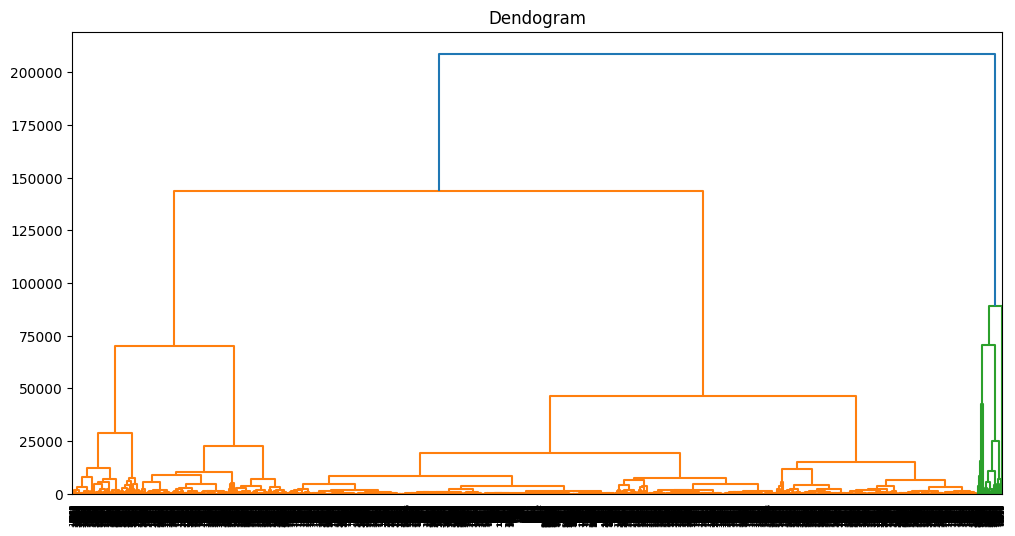

In [ ]:
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendogram')
plt.show()